Number of evaluated images: 289
Mean Classical Dice: 0.1883


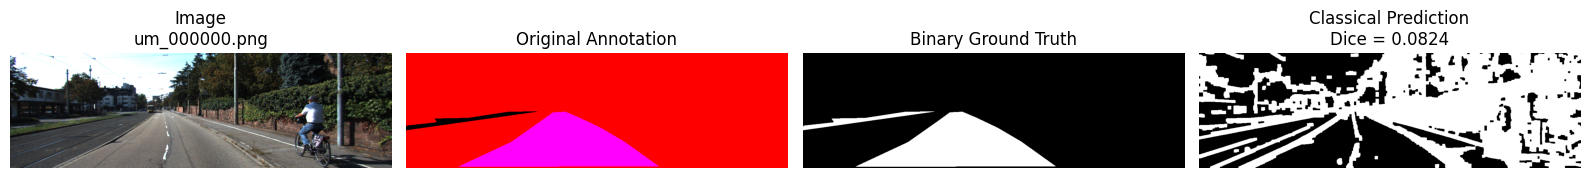

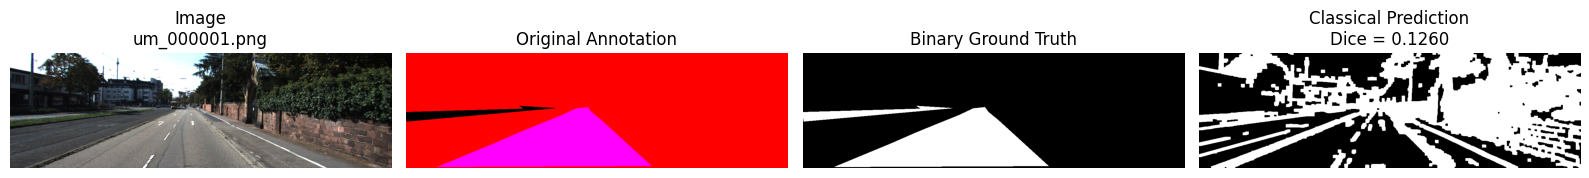

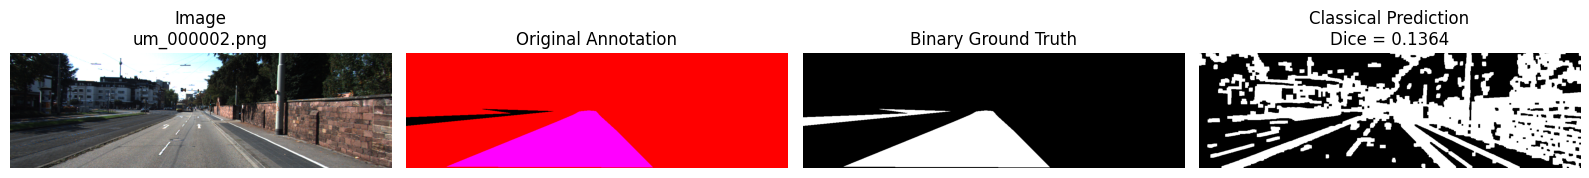

Worst example: uu_000075.png, Dice = 0.0221
Best example: uu_000010.png, Dice = 0.4256


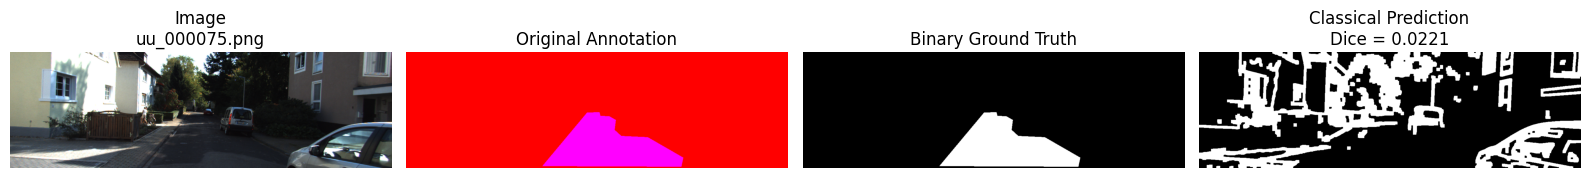

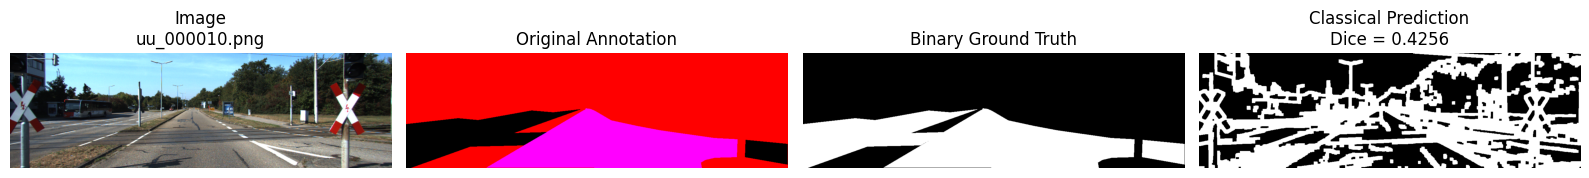

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = "../data/training/image_2"
MASK_DIR = "../data/training/gt_image_2"


def get_mask_name(img_name):
    stem = img_name.replace(".png", "")
    prefix, idx = stem.split("_", 1)
    return f"{prefix}_road_{idx}.png"


def load_image_and_gt(img_name, image_dir=IMAGE_DIR, mask_dir=MASK_DIR):

    img_path = os.path.join(image_dir, img_name)
    mask_name = get_mask_name(img_name)
    mask_path = os.path.join(mask_dir, mask_name)

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    mask_bgr = cv2.imread(mask_path)
    if mask_bgr is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)

    flat = mask_rgb.reshape(-1, 3)
    colors, counts = np.unique(flat, axis=0, return_counts=True)
    background_color = colors[np.argmax(counts)]

    gt = np.any(mask_rgb != background_color, axis=-1)

    return img, gt, mask_rgb


def classical_baseline(img):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    kernel = np.ones((5, 5), np.uint8)
    pred = cv2.dilate(edges, kernel, iterations=2)
    pred = cv2.morphologyEx(pred, cv2.MORPH_CLOSE, kernel)

    return pred > 0


def dice_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    return 2 * intersection / (pred.sum() + gt.sum() + 1e-8)


def evaluate_all(image_dir=IMAGE_DIR):

    img_names = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])
    results = []

    for img_name in img_names:
        try:
            img, gt, _ = load_image_and_gt(img_name)
            pred = classical_baseline(img)
            d = dice_score(pred, gt)
            results.append((img_name, d))
        except FileNotFoundError as e:
            print(e)

    mean_dice = np.mean([d for _, d in results]) if results else 0.0
    return results, mean_dice


def show_examples(image_names, image_dir=IMAGE_DIR):
    """
    Visualize selected examples.
    """
    for img_name in image_names:
        img, gt, original_mask, = load_image_and_gt(img_name)
        pred = classical_baseline(img)
        d = dice_score(pred, gt)

        plt.figure(figsize=(16, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(img)
        plt.title(f"Image\n{img_name}")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(original_mask)
        plt.title("Original Annotation")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(gt, cmap="gray")
        plt.title("Binary Ground Truth")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(pred, cmap="gray")
        plt.title(f"Classical Prediction\nDice = {d:.4f}")
        plt.axis("off")

        plt.tight_layout()
        plt.show()



results, mean_dice = evaluate_all()

print(f"Number of evaluated images: {len(results)}")
print(f"Mean Classical Dice: {mean_dice:.4f}")

# Show examples
example_names = [name for name, _ in results[:3]]
show_examples(example_names)


if results:
    results_sorted = sorted(results, key=lambda x: x[1])
    worst_name, worst_dice = results_sorted[0]
    best_name, best_dice = results_sorted[-1]

    print(f"Worst example: {worst_name}, Dice = {worst_dice:.4f}")
    print(f"Best example: {best_name}, Dice = {best_dice:.4f}")

    show_examples([worst_name, best_name])